# Topic: SHAP Values

## Definition (30-second explanation)
* SHAP (SHapley Additive exPlanations) is a unified framework for explaining the output of any machine learning model. 
* It is based on cooperative game theory, specifically Shapley values, and assigns a contribution score to each feature for individual predictions.

## Why Interviewers Ask This
* To test if you can make black-box models explainable, which is essential for regulated industries requiring model transparency and fairness.
* To evaluate your understanding of fulfilling legal frameworks, such as satisfying 'right to explanation' requirements under GDPR and fair lending laws.

## Core Concepts
* **Base Value:** The expected model output over the training dataset, serving as the baseline prediction.
* **SHAP Value:** The measure of how much a specific feature pushed the prediction above or below the base value. A positive SHAP value means the feature pushes the prediction higher, while a negative value pushes it lower.
* **Additive Property:** The final prediction is simply the base value plus the sum of all individual SHAP values for that specific sample.
* **Global vs. Local:** Global explanations evaluate mean absolute SHAP values across all samples for overall importance, whereas local explanations evaluate the SHAP values for one specific prediction.

## When to Use
* When you need both global explanations (overall feature impact) and local explanations (why the model made a specific prediction for one sample).
* When model decisions directly impact humans (e.g., loan approvals, healthcare) and you must provide a detailed breakdown of the decision.

## Advantages
* Provides a mathematically robust, unified approach that guarantees the additive property.
* `TreeExplainer` provides fast and exact SHAP value computations for tree-based models like Random Forest, XGBoost, and LightGBM.

## Limitations
* For non-tree models (like neural networks), computation relies on `KernelExplainer` or `DeepExplainer`, which are approximate and can be very slow to compute on large datasets.

## Common Comparisons
* **TreeExplainer vs. KernelExplainer:** `TreeExplainer` is fast and exact but limited to tree models, while `KernelExplainer` is slower and approximate but model-agnostic (works with any model).
* **Summary Plot vs. Waterfall Plot:** A summary plot provides a global overview of the most impactful features across all data, whereas a waterfall plot provides a single prediction breakdown (local explanation).

## Common Interview Traps
* **Mistake 1:** Claiming SHAP values are always fast and exact. They are only exact for tree models; they are approximations for neural networks and can be highly computationally expensive.
* **Mistake 2:** Failing to mention the three key plots (summary, waterfall, and dependence plots) when asked how you would present SHAP findings to a stakeholder.

## Python Syntax
```python
import shap
import pandas as pd
import numpy as np

# Create SHAP explainer (fast TreeExplainer for tree-based models)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Global importance: mean absolute SHAP
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0), 
    index=X.columns
).sort_values(ascending=False)
print("Top 5 features by SHAP:\n", mean_shap.head())

# Local explanation for sample 0
base_val = explainer.expected_value
```

##Important Formula
- SHAP Decomposition Formula:
$f(x) = base\_value + SHAP\_1 + SHAP\_2 + ... + SHAP\_n$

## 45-Second Interview Answer
"SHAP is an interpretability framework based on game theory that explains machine learning models by assigning a contribution score to each feature. Its biggest advantage is that it provides both global explanations—showing which features matter most overall—and local explanations, breaking down exactly why a specific prediction was made. Because of its additive property, the baseline expected value plus the sum of the individual SHAP values equals the final prediction exactly. It is computationally fast for tree models using TreeExplainer, but can be slow for deep learning models."

## Practice Questions:

### Q1: A bank's loan default model was rejected by regulators because it was a black box. How would you use SHAP to make it explainable?
* **Answer:** I would use SHAP to provide two levels of explanation. First, for global explainability, I would generate a SHAP summary plot to show regulators the most impactful features across all loans, proving what the model relies on overall. Second, for local explainability, I would generate a SHAP waterfall plot for each rejected application. This shows exactly why a specific customer was rejected (e.g., 'debt ratio contributed +0.35 to rejection'), satisfying the 'right to explanation' under fair lending laws.
* **Common Mistakes:** Explaining the math behind Shapley values to the regulator instead of focusing on the tangible deliverables (Summary and Waterfall plots) that solve the business problem.
* **Likely Follow-up:** If the model in this scenario was a deep neural network instead of a Random Forest, how would your approach to computing SHAP change?

### Q2:
**You have just trained a LightGBM model to predict housing prices and you want to present your findings to the real estate agency.**

- Using the shap library, write the Python code to:
- Generate a global summary plot (bar chart style) to show the overall feature importances to the stakeholders.
- Generate a local waterfall plot for the very first house in your test set to explain its specific price prediction.

In [17]:
# Data:
import shap
import pandas as pd
import lightgbm as lgb
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# Mock Schema & Data Setup
data = fetch_california_housing(as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

model = lgb.LGBMRegressor(random_state=42)
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000609 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947


,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


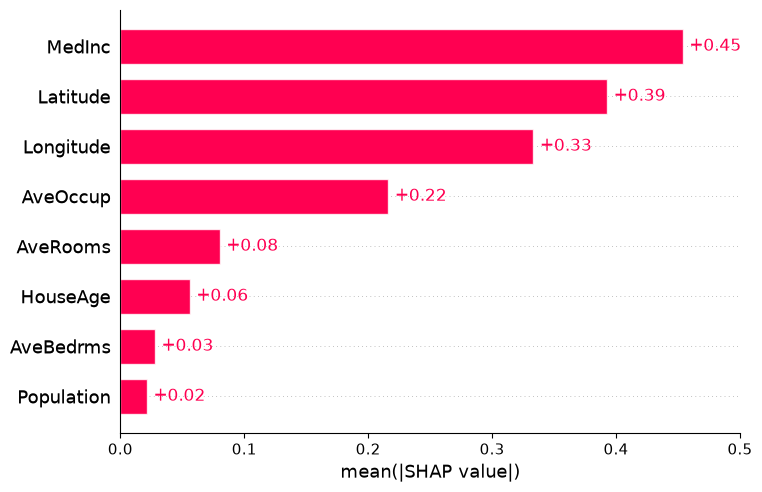

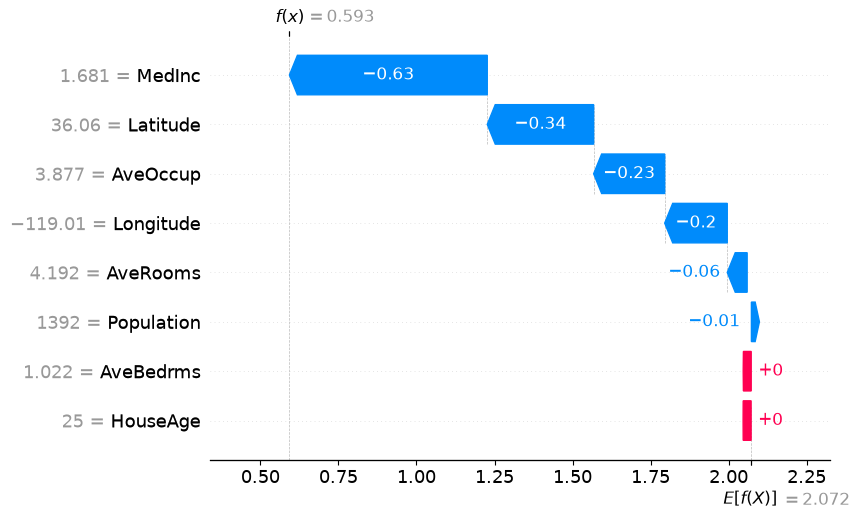

In [18]:
# 1. Initialize the explainer using the trained model
explainer = shap.TreeExplainer(model)

# 2. Calculate SHAP values (creates an Explanation object)
shap_values = explainer(X_test)

# 3. Global Explanation: Summary Bar Plot (shows top features across all data)
shap.plots.bar(shap_values)

# 4. Local Explanation: Waterfall Plot for the first house (index 0)
shap.plots.waterfall(shap_values[0])

### Q3: How do you interpret a SHAP waterfall plot to a stakeholder?
* **Ideal Answer:** "A waterfall plot explains a single, local prediction. I would explain that we start at the 'base value' at the bottom, which is the average prediction across all our data. Then, reading upwards, each bar represents a specific feature for this specific customer. Red bars push the prediction higher than average, and blue bars push it lower. The sum of the base value and all these individual feature impacts equals the final prediction shown at the very top."
* **Common Mistakes:** Confusing a waterfall plot (which explains one single row of data) with a summary/bar plot (which explains the entire dataset on average).

### Q4: What is the SHAP Base Value?
* **Ideal Answer:** The base value, often denoted as $E[f(X)]$, is the expected value or the mean prediction of the model across the training background dataset. It serves as the starting baseline for the additive SHAP calculations.